## Step 1: Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2

## Step 2: Load the Dataset

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

In [3]:
print(type(data))

<class 'sklearn.utils._bunch.Bunch'>


## Step 3: Explore the Dataset

In [4]:
print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [5]:
print(data.feature_names)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [6]:
print(data.target_names)

['malignant' 'benign']


In [7]:
print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (569, 30)
Labels shape: (569,)


In [8]:
df = pd.DataFrame(X, columns=data.feature_names)

df["target"] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [9]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [11]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [12]:
print(df["target"].value_counts())

target
1    357
0    212
Name: count, dtype: int64


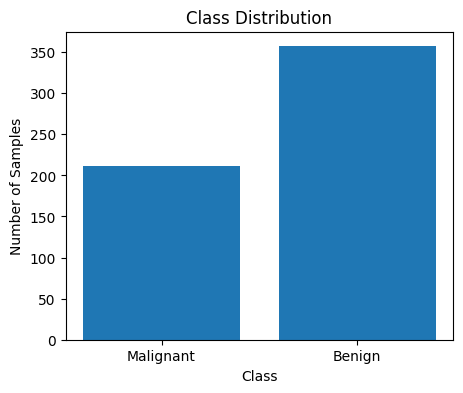

In [13]:
plt.figure(figsize=(5, 4))

plt.bar(
    ["Malignant", "Benign"],
    df["target"].value_counts().sort_index()
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.show()

## Step 4: Data Preprocessing

### Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Features: (455, 30)
Testing Features : (114, 30)
Training Labels : (455,)
Testing Labels  : (114,)


### Create the Scaler

In [16]:
scaler = StandardScaler()

### Fit on Training Data

In [17]:
scaler.fit(X_train)

StandardScaler()

### Transform the Data

In [18]:
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

### Verify the Scaling

In [19]:
print("Mean:", np.mean(X_train))
print("Standard Deviation:", np.std(X_train))

Mean: -9.442670495742283e-16
Standard Deviation: 1.0


In [20]:
print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


## Step 5: Build the Baseline MLP

In [21]:
from tensorflow.keras import Input

model = Sequential([
    Input(shape=(30,)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

## Step 6: Compile the Model

In [22]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## Step 7: Train the Model

In [23]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.7857 - loss: 0.5388 - val_accuracy: 0.9341 - val_loss: 0.3711
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9368 - loss: 0.3036 - val_accuracy: 0.9341 - val_loss: 0.2418
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9505 - loss: 0.2056 - val_accuracy: 0.9451 - val_loss: 0.1873
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9588 - loss: 0.1554 - val_accuracy: 0.9451 - val_loss: 0.1553
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9615 - loss: 0.1234 - val_accuracy: 0.9451 - val_loss: 0.1357
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9725 - loss: 0.1037 - val_accuracy: 0.9560 - val_loss: 0.1223
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9835 - loss: 0.0879 - val_accuracy: 0.9670 - val_loss: 0.1125
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9808 - loss: 0.0779 - val_accuracy: 0.9670 - 

## Step 8: Visualize Training History

In [24]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


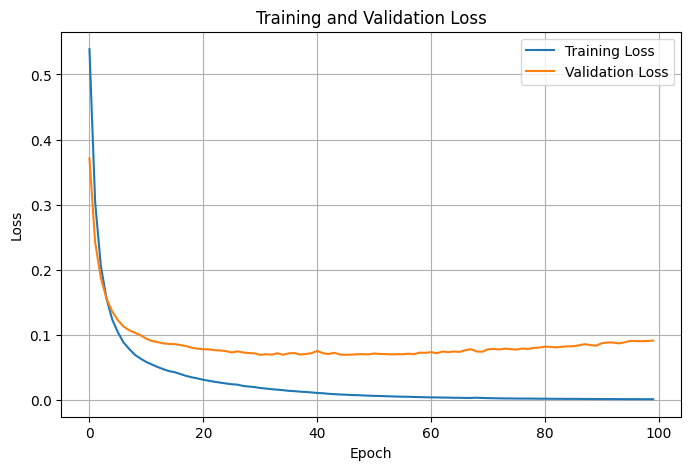

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

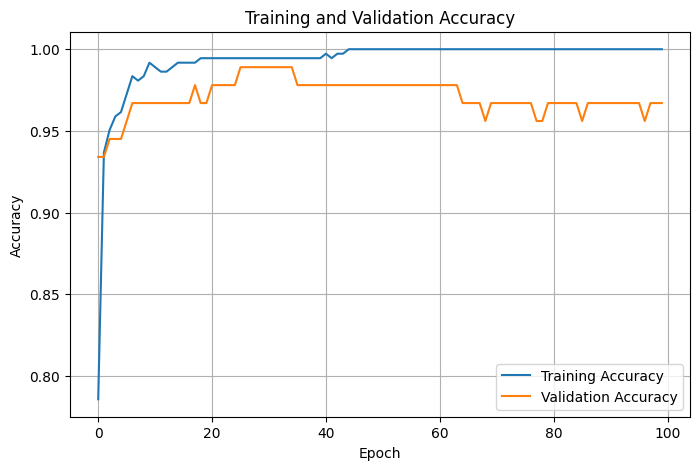

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

## Step 9: Evaluate the Model

In [27]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.1229
Test Accuracy: 0.9649


In [28]:
y_pred_prob = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


In [29]:
y_pred = (y_pred_prob >= 0.5).astype(int)

In [31]:
print(y_pred[:5])

[[1]
 [0]
 [0]
 [1]
 [1]]


In [32]:
print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

              precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



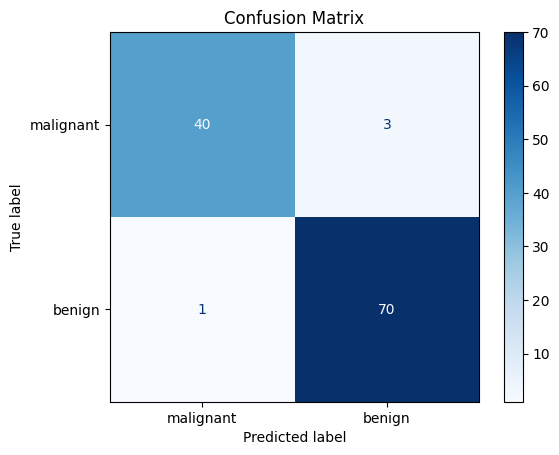

In [33]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [34]:
auc = roc_auc_score(y_test, y_pred_prob)

print(f"ROC-AUC Score: {auc:.4f}")

ROC-AUC Score: 0.9931


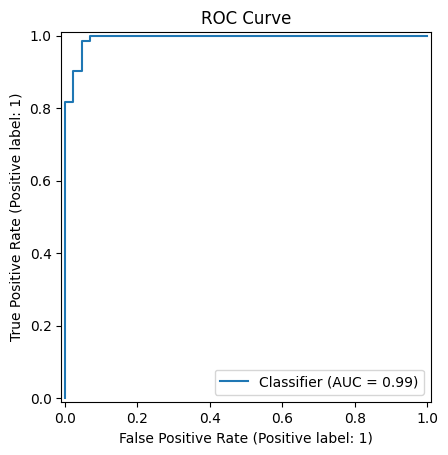

In [35]:
RocCurveDisplay.from_predictions(y_test, y_pred_prob)

plt.title("ROC Curve")
plt.show()

## Step 10: Apply Dropout Regularization

In [36]:
dropout_model = Sequential([
    Input(shape=(30,)),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

In [37]:
dropout_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [38]:
dropout_history = dropout_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.6181 - loss: 0.6191 - val_accuracy: 0.9231 - val_loss: 0.4048
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8544 - loss: 0.3974 - val_accuracy: 0.9341 - val_loss: 0.2803
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9176 - loss: 0.2922 - val_accuracy: 0.9560 - val_loss: 0.2158
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9286 - loss: 0.2346 - val_accuracy: 0.9451 - val_loss: 0.1764
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9423 - loss: 0.1986 - val_accuracy: 0.9560 - val_loss: 0.1520
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9423 - loss: 0.1637 - val_accuracy: 0.9560 - val_loss: 0.1351
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9615 - loss: 0.1468 - val_accuracy: 0.9560 - val_loss: 0.1228
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9615 - loss: 0.1244 - val_accuracy: 0.

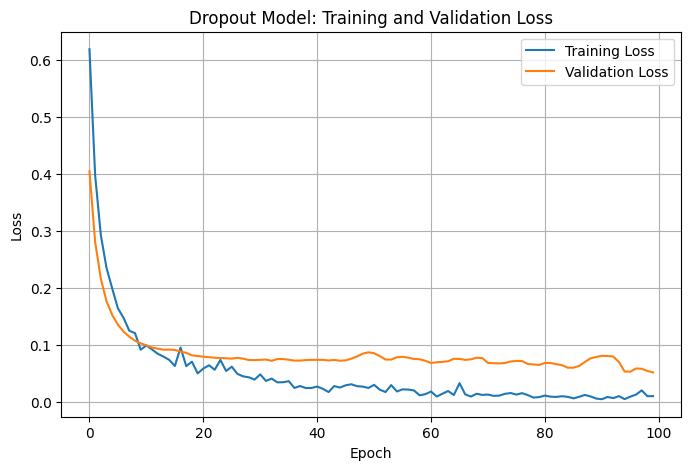

In [39]:
plt.figure(figsize=(8,5))

plt.plot(dropout_history.history["loss"], label="Training Loss")
plt.plot(dropout_history.history["val_loss"], label="Validation Loss")

plt.title("Dropout Model: Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

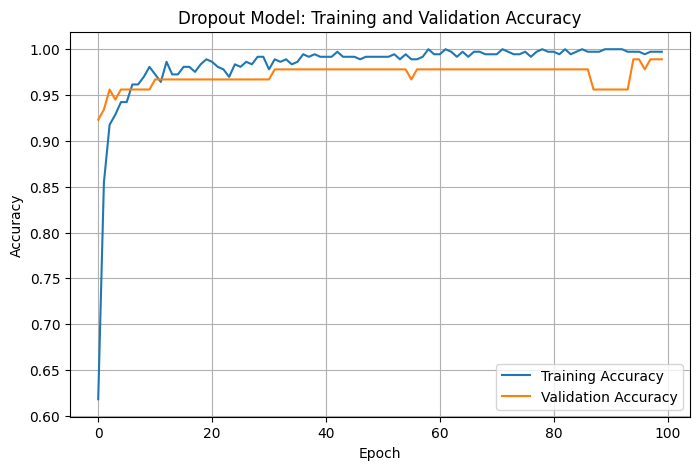

In [40]:
plt.figure(figsize=(8,5))

plt.plot(dropout_history.history["accuracy"], label="Training Accuracy")
plt.plot(dropout_history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Dropout Model: Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [41]:
test_loss, test_accuracy = dropout_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.1146
Test Accuracy: 0.9737


In [42]:
y_pred_prob = dropout_model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


In [43]:
print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



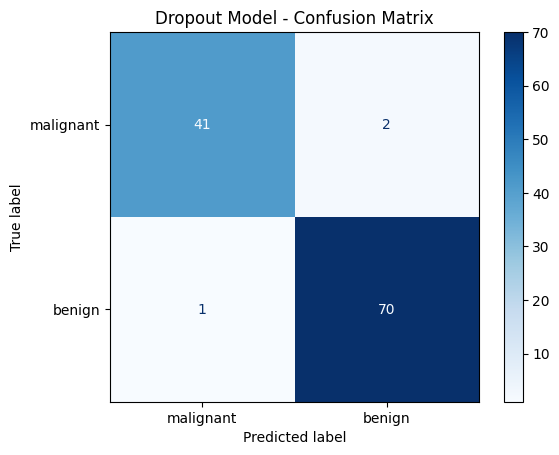

In [44]:
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
).plot(cmap="Blues")

plt.title("Dropout Model - Confusion Matrix")
plt.show()

In [45]:
auc = roc_auc_score(y_test, y_pred_prob)

print(f"ROC-AUC Score: {auc:.4f}")

ROC-AUC Score: 0.9938


## Step 11: Apply L2 Regularization

In [46]:
l2_model = Sequential([
    Input(shape=(30,)),
    Dense(
        64,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),
    Dense(
        32,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),
    Dense(
        1,
        activation="sigmoid",
        kernel_regularizer=l2(0.001)
    )
])

In [47]:
l2_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [48]:
l2_history = l2_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7720 - loss: 0.6303 - val_accuracy: 0.9121 - val_loss: 0.4599
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9341 - loss: 0.3967 - val_accuracy: 0.9231 - val_loss: 0.3315
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9478 - loss: 0.2940 - val_accuracy: 0.9341 - val_loss: 0.2746
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9560 - loss: 0.2421 - val_accuracy: 0.9341 - val_loss: 0.2459
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9615 - loss: 0.2134 - val_accuracy: 0.9560 - val_loss: 0.2260
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9670 - loss: 0.1924 - val_accuracy: 0.9670 - val_loss: 0.2135
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.9725 - loss: 0.1777 - val_accuracy: 0.9670 - val_loss: 0.2045
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9808 - loss: 0.1680 - val_accuracy: 0.

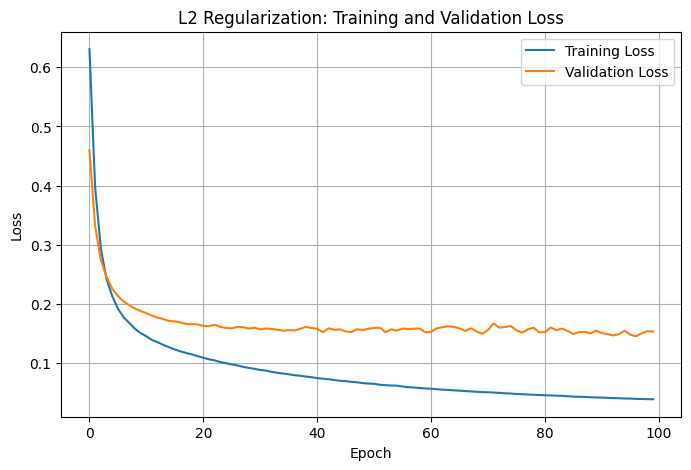

In [49]:
plt.figure(figsize=(8, 5))

plt.plot(l2_history.history["loss"], label="Training Loss")
plt.plot(l2_history.history["val_loss"], label="Validation Loss")

plt.title("L2 Regularization: Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

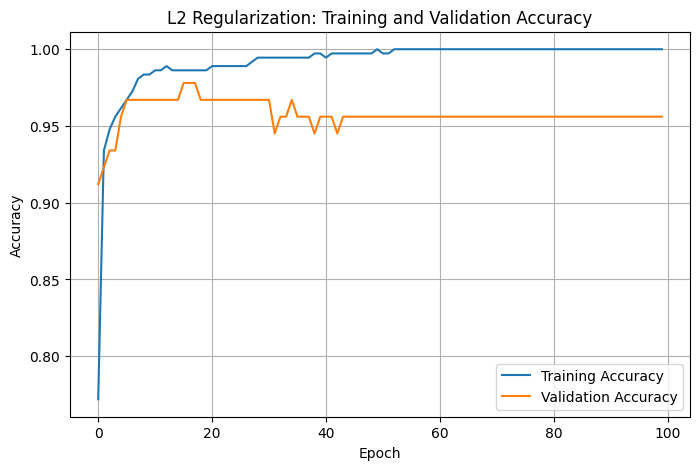

In [50]:
plt.figure(figsize=(8, 5))

plt.plot(l2_history.history["accuracy"], label="Training Accuracy")
plt.plot(l2_history.history["val_accuracy"], label="Validation Accuracy")

plt.title("L2 Regularization: Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [51]:
test_loss, test_accuracy = l2_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.1307
Test Accuracy: 0.9737


In [52]:
y_pred_prob = l2_model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


In [53]:
print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

              precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        43
      benign       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



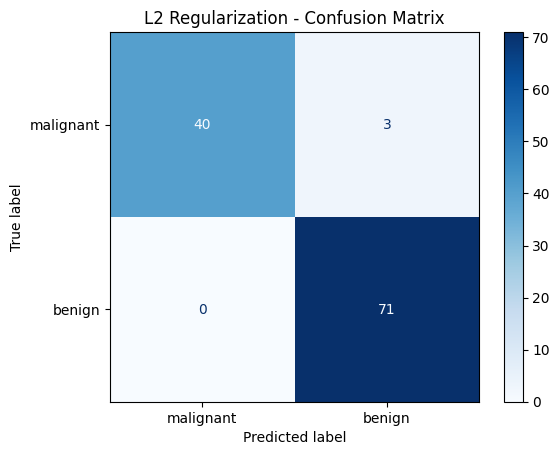

In [54]:
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
).plot(cmap="Blues")

plt.title("L2 Regularization - Confusion Matrix")
plt.show()

In [55]:
auc = roc_auc_score(y_test, y_pred_prob)

print(f"ROC-AUC Score: {auc:.4f}")

ROC-AUC Score: 0.9921


## Step 12: Combine Dropout and L2 Regularization

In [56]:
combined_model = Sequential([
    Input(shape=(30,)),

    Dense(
        64,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),
    Dropout(0.3),

    Dense(
        32,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),
    Dropout(0.3),

    Dense(
        1,
        activation="sigmoid",
        kernel_regularizer=l2(0.001)
    )
])

In [57]:
combined_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [58]:
combined_history = combined_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.5330 - loss: 0.7815 - val_accuracy: 0.8571 - val_loss: 0.5956
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8462 - loss: 0.5486 - val_accuracy: 0.9231 - val_loss: 0.4441
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8984 - loss: 0.4313 - val_accuracy: 0.9121 - val_loss: 0.3559
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9258 - loss: 0.3438 - val_accuracy: 0.9231 - val_loss: 0.3021
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9423 - loss: 0.2923 - val_accuracy: 0.9560 - val_loss: 0.2647
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9396 - loss: 0.2646 - val_accuracy: 0.9451 - val_loss: 0.2394
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9505 - loss: 0.2283 - val_accuracy: 0.9560 - val_loss: 0.2215
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9451 - loss: 0.2314 - val_accuracy: 0.

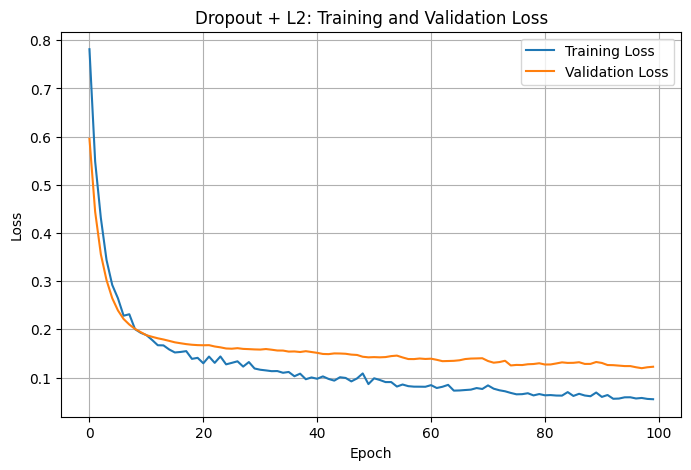

In [59]:
plt.figure(figsize=(8, 5))

plt.plot(combined_history.history["loss"], label="Training Loss")
plt.plot(combined_history.history["val_loss"], label="Validation Loss")

plt.title("Dropout + L2: Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

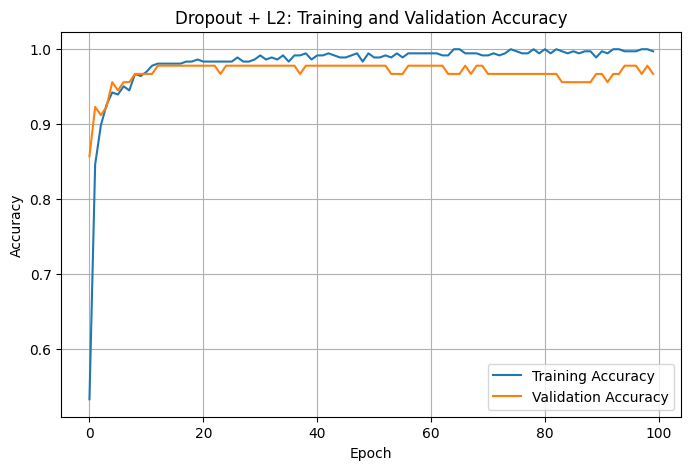

In [60]:
plt.figure(figsize=(8, 5))

plt.plot(combined_history.history["accuracy"], label="Training Accuracy")
plt.plot(combined_history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Dropout + L2: Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [61]:
test_loss, test_accuracy = combined_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.1259
Test Accuracy: 0.9825


In [62]:
y_pred_prob = combined_model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


In [63]:
print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        43
      benign       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



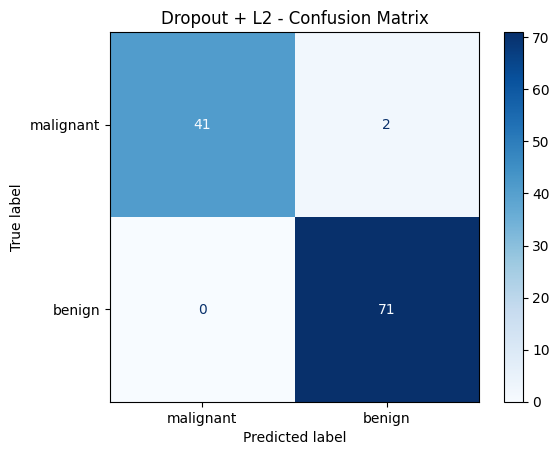

In [64]:
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
).plot(cmap="Blues")

plt.title("Dropout + L2 - Confusion Matrix")
plt.show()

In [65]:
auc = roc_auc_score(y_test, y_pred_prob)

print(f"ROC-AUC Score: {auc:.4f}")

ROC-AUC Score: 0.9948
